In [5]:
import os
from pathlib import Path
import numpy as np
import scipy.io as sio # For loading .mat files
import matplotlib.pyplot as plt
from scipy.signal import welch # For power spectral density estimation

# SEED dataset paths on hydra cluster
SEED_ROOT = Path("/home/space/datasets/bsa03/SEED") # Locate SEED dataset root directory
PREPROCESSED_DIR = SEED_ROOT / "Preprocessed_EEG" # Directory containing preprocessed .mat files

# SEED metadata (from official documentation)
FS = 200                # Frequency of Sampling(Hz) 200/s records — already downsampled by SJTU
N_CHANNELS = 62         # 62 EEG channels

# Sanity check: list first few files
mat_files = sorted([f for f in PREPROCESSED_DIR.iterdir() if f.suffix == ".mat"]) # List all .mat files in the preprocessed directory, sorted alphabetically
print(f"Found {len(mat_files)} .mat files in {PREPROCESSED_DIR}") 
print("First 5 files:")
for f in mat_files[:5]:
    print(f"  {f.name}")

Found 46 .mat files in /home/space/datasets/bsa03/SEED/Preprocessed_EEG
First 5 files:
  10_20131130.mat
  10_20131204.mat
  10_20131211.mat
  11_20140618.mat
  11_20140625.mat


In [ ]:
# Inspect variables inside one .mat file

# Pick the first subject's first session
sample_file = mat_files[0]
print(f"Loading: {sample_file.name}\n") 

mat = sio.loadmat(sample_file) # Load the .mat file using scipy.io into a Python dictionary, keys are variable names, values are numpy arrays

# .mat files always contain meta keys starting with "__" — filter them out
data_keys = [k for k in mat.keys() if not k.startswith("__")]
print(f"Number of variables: {len(data_keys)}") # Expected 15 
print(f"Variable names: {data_keys}\n")

# Show shape of each variable
print("Variable shapes (channels × time_points):")
for key in data_keys:
    arr = mat[key]
    print(f"  {key:20s} shape={arr.shape}  dtype={arr.dtype}") # Normalize the shape of each variables for 20 characters

Loading: 10_20131130.mat

Number of variables: 15
Variable names: ['ww_eeg1', 'ww_eeg2', 'ww_eeg3', 'ww_eeg4', 'ww_eeg5', 'ww_eeg6', 'ww_eeg7', 'ww_eeg8', 'ww_eeg9', 'ww_eeg10', 'ww_eeg11', 'ww_eeg12', 'ww_eeg13', 'ww_eeg14', 'ww_eeg15']

Variable shapes (channels × time_points):
  ww_eeg1              shape=(62, 47001)  dtype=float64
  ww_eeg2              shape=(62, 46601)  dtype=float64
  ww_eeg3              shape=(62, 41201)  dtype=float64
  ww_eeg4              shape=(62, 47601)  dtype=float64
  ww_eeg5              shape=(62, 37001)  dtype=float64
  ww_eeg6              shape=(62, 39001)  dtype=float64
  ww_eeg7              shape=(62, 47401)  dtype=float64
  ww_eeg8              shape=(62, 43201)  dtype=float64
  ww_eeg9              shape=(62, 53001)  dtype=float64
  ww_eeg10             shape=(62, 47401)  dtype=float64
  ww_eeg11             shape=(62, 47001)  dtype=float64
  ww_eeg12             shape=(62, 46601)  dtype=float64
  ww_eeg13             shape=(62, 47001)  dtype

In [ ]:
# Inspect another variable in mat files
sample_file2 = [f for f in mat_files if f.name.startswith("11_")][0]
print(f"\nLoading: {sample_file2.name}\n")
mat2 = sio.loadmat(sample_file2)
data_keys2 = [k for k in mat2.keys() if not k.startswith("__")]
print(f"Number of variables: {len(data_keys2)}") # Expected 15
print(f"Variable names: {data_keys2}\n")
print("Variable shapes (channels × time_points):")
for key in data_keys2:
    arr = mat2[key]
    print(f"  {key:20s} shape={arr.shape}  dtype={arr.dtype}")
    


Loading: 11_20140618.mat

Number of variables: 15
Variable names: ['wsf_eeg1', 'wsf_eeg2', 'wsf_eeg3', 'wsf_eeg4', 'wsf_eeg5', 'wsf_eeg6', 'wsf_eeg7', 'wsf_eeg8', 'wsf_eeg9', 'wsf_eeg10', 'wsf_eeg11', 'wsf_eeg12', 'wsf_eeg13', 'wsf_eeg14', 'wsf_eeg15']

Variable shapes (channels × time_points):
  wsf_eeg1             shape=(62, 47001)  dtype=float64
  wsf_eeg2             shape=(62, 46601)  dtype=float64
  wsf_eeg3             shape=(62, 41201)  dtype=float64
  wsf_eeg4             shape=(62, 47601)  dtype=float64
  wsf_eeg5             shape=(62, 37001)  dtype=float64
  wsf_eeg6             shape=(62, 39001)  dtype=float64
  wsf_eeg7             shape=(62, 47401)  dtype=float64
  wsf_eeg8             shape=(62, 43201)  dtype=float64
  wsf_eeg9             shape=(62, 53001)  dtype=float64
  wsf_eeg10            shape=(62, 47401)  dtype=float64
  wsf_eeg11            shape=(62, 47001)  dtype=float64
  wsf_eeg12            shape=(62, 46601)  dtype=float64
  wsf_eeg13            shape=(6

In [ ]:
# Convert shapes to durations and total samples

# Each variable should be one trial (one movie clip)
# shape = (channels, time_points), so duration = time_points / FS

print(f"Sampling rate: {FS} Hz\n") # Print the sampling rate for reference when calculating durations
print(f"{'Trial':<20s} {'Channels':<10s} {'Samples':<10s} {'Duration (s)':<12s}") # Print header for the table of trial information, normalize the width of each column for better readability  
print("-" * 55) # Print a separator line for better readability

total_samples = 0 # Initialize a counter for total samples across all trials, to be used for calculating total duration at the end
for key in data_keys:
    arr = mat[key] # Get the numpy array for the current variable (trial)
    n_ch, n_samples = arr.shape # Get the number of channels and samples (time points) from the shape of the array
    duration_s = n_samples / FS # Calculate the duration of the trial in seconds
    total_samples += n_samples 
    print(f"{key:<20s} {n_ch:<10d} {n_samples:<10d} {duration_s:<12.1f}")

print(f"\nTotal samples in this file: {total_samples}")
print(f"Total duration: {total_samples / FS:.1f} s ({total_samples / FS / 60:.1f} min)")

# The results show that each trial has duration of around 4 minutes(185s-265s), which matches the official documentation that each movie clip is around 4 minutes long. 


Sampling rate: 200 Hz

Trial                Channels   Samples    Duration (s)
-------------------------------------------------------
ww_eeg1              62         47001      235.0       
ww_eeg2              62         46601      233.0       
ww_eeg3              62         41201      206.0       
ww_eeg4              62         47601      238.0       
ww_eeg5              62         37001      185.0       
ww_eeg6              62         39001      195.0       
ww_eeg7              62         47401      237.0       
ww_eeg8              62         43201      216.0       
ww_eeg9              62         53001      265.0       
ww_eeg10             62         47401      237.0       
ww_eeg11             62         47001      235.0       
ww_eeg12             62         46601      233.0       
ww_eeg13             62         47001      235.0       
ww_eeg14             62         47601      238.0       
ww_eeg15             62         41201      206.0       

Total samples in this fi

ww_eeg1


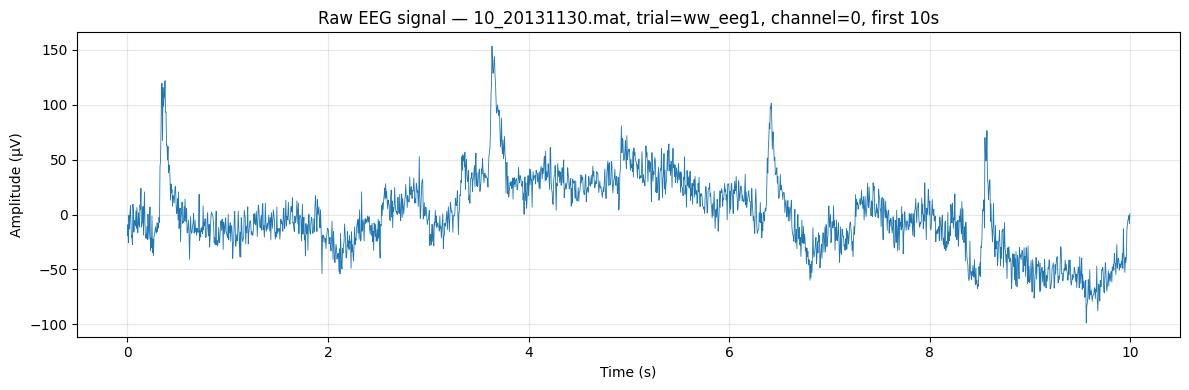

In [ ]:
# Visualize raw signal from one channel of one trial

# Pick the first trial, first channel, first 10 seconds
trial_key = data_keys[0] 
print(trial_key)
signal = mat[trial_key]   # shape (62, N)

channel_idx = 0           # Select FP1 (first channel)
n_seconds = 10  # Select first 10 seconds for visualization
n_samples_plot = n_seconds * FS # 2000 samples for 10 seconds at 200 Hz

time_axis = np.arange(n_samples_plot) / FS # Create a time axis in seconds for the x-axis of the plot

plt.figure(figsize=(12, 4)) 
plt.plot(time_axis, signal[channel_idx, :n_samples_plot], linewidth=0.6)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (μV)")
plt.title(f"Raw EEG signal — {sample_file.name}, trial={trial_key}, "
          f"channel={channel_idx}, first {n_seconds}s")
plt.grid(alpha=0.3) # Add a light grid for better readability
plt.tight_layout()
plt.show()

# The plot shows the raw EEG signal from the first channel (FP1) of the first trial of subject 10 for the first 10 seconds. 
# We can see the artifacts and noise which is higher than 50 μV(common EEG amplitude), which needs to be cleaned in the preprocessing step.
# This might be caused by eye blinks, muscle movements, or other sources of noise.
# This gives us a sense of the data quality and what we are working with before we move on to preprocessing and analysis steps.

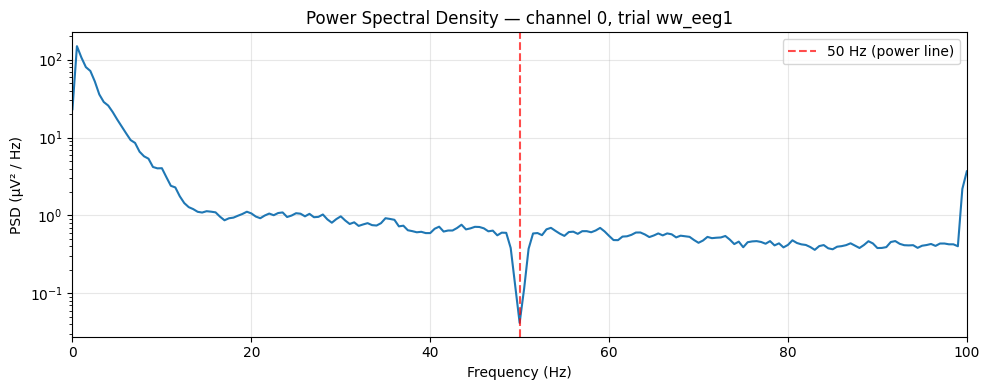


Observations to note:
  - SJTU pre-applied a 0–75 Hz bandpass, so power above 75 Hz should be near zero.
  - Check whether a 50 Hz peak is visible → decide if notch filter is needed.


In [ ]:
# Next, let's look at the power spectral density (PSD) of the same channel to check for noise characteristics, especially around 50 Hz which is common for EEG.

freqs, psd = welch(signal[channel_idx], fs=FS, nperseg=FS * 2) # Use Welch's method to estimate the power spectral density of the selected channel, with a segment length of 2 seconds (400 samples at 200 Hz) for better frequency resolution

plt.figure(figsize=(10, 4))
plt.semilogy(freqs, psd) # x-axis is frequency in Hz, y-axis is power spectral density in μV²/Hz, plotted on a logarithmic scale for better visibility of peaks
plt.axvline(50, color="red", linestyle="--", alpha=0.7, label="50 Hz (power line)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (μV² / Hz)")
plt.title(f"Power Spectral Density — channel {channel_idx}, trial {trial_key}")
plt.xlim(0, 100) # Limit x-axis to 100 Hz since we are mainly interested in the lower frequencies for EEG and to check for 50 Hz noise
plt.legend()
plt.grid(alpha=0.3) 
plt.tight_layout()
plt.show()

print("\nObservations to note:")
print("  - SJTU pre-applied a 0–75 Hz bandpass, so power above 75 Hz should be near zero.")
print("  - Check whether a 50 Hz peak is visible → decide if notch filter is needed.")

# The PSD plot shows the distribution of power across frequencies for the selected channel and trial.
# We should see that the power drops off above 50 Hz due to the bandpass filter, therefore no notch filter is needed for 50 Hz power line noise.

In [13]:
# Load the label file
# ---------------------------------------------------------------
# The label file lives at SEED_ROOT / "Preprocessed_EEG" / "label.mat"
# (or sometimes in the root SEED folder — check both)
label_candidates = [
    PREPROCESSED_DIR / "label.mat",
    SEED_ROOT / "label.mat",
]
for path in label_candidates:
    if path.exists():
        print(f"Found label file: {path}")
        labels = sio.loadmat(path)
        for k in labels.keys():
            if not k.startswith("__"):
                print(f"  {k}: shape={labels[k].shape}, values={labels[k].flatten()}")
        break
else:
    print("label.mat not found in expected locations — list SEED root contents:")
    for f in SEED_ROOT.iterdir():
        print(f"  {f.name}")

Found label file: /home/space/datasets/bsa03/SEED/Preprocessed_EEG/label.mat
  label: shape=(1, 15), values=[ 1  0 -1 -1  0  1 -1  0  1  1  0 -1  0  1 -1]


In [ ]:
# test: Confirm extract_de_features_2s function works and outputs expected shape and values
import sys
sys.path.insert(0, '/home/bsa03/DLBSA-SEED-EEG')  

import importlib
import preprocessing
importlib.reload(preprocessing)

from preprocessing import extract_de_features_2s
import numpy as np
import scipy.io as sio

# Load a sample .mat file to test the feature extraction function
test_mat = "/home/space/datasets/bsa03/SEED/Preprocessed_EEG/1_20131027.mat"
mat = sio.loadmat(test_mat)

# Use the first trial for testing
eeg_keys = sorted([k for k in mat.keys() 
                    if not k.startswith("__") and mat[k].shape[0] == 62],
                  key=lambda k: int(''.join(c for c in k if c.isdigit())))

trial_signal = mat[eeg_keys[0]]
print(f"Input shape: {trial_signal.shape}")

features = extract_de_features_2s(trial_signal, fs=200)

print(f"\nOutput shape:  {features.shape}")
print(f"Output dtype:  {features.dtype}")
print(f"Has NaN?       {np.any(np.isnan(features))}")
print(f"Has Inf?       {np.any(np.isinf(features))}")
print(f"Min:           {features.min():.4f}")
print(f"Max:           {features.max():.4f}")
print(f"Mean:          {features.mean():.4f}")
print(f"Std:           {features.std():.4f}")

Input shape: (62, 47001)

Output shape:  (119, 62, 5)
Output dtype:  float64
Has NaN?       False
Has Inf?       False
Min:           -6.7514
Max:           2.5147
Mean:          0.0000
Std:           1.0000
